# Introduction to Biostatistics — Visualizations

**Part 3: Visualizing the Data**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(1)

## Part 1: Summary Statistics Recap

Before visualizing data, compute some key summary statistics on a small sample dataset. Note the outlier value of 2500.

In [2]:
sample_data = np.array([120, 145, 130, 200, 155, 165, 2500, 175, 190, 150])

In [3]:
# Mean and median
print("Mean:  ", np.mean(sample_data))
print("Median:", np.median(sample_data))

Mean:   393.0
Median: 160.0


In [4]:
# Variance and standard deviation (ddof=1 for sample statistics)
print("Variance:", np.var(sample_data, ddof=1))
print("Std Dev: ", np.std(sample_data, ddof=1))

Variance: 548701.1111111111
Std Dev:  740.7436203647732


In [5]:
# Percentiles
probs = [1, 3, 25, 50, 75, 95, 99]
for p in probs:
    print(f"  {p:>2}th percentile: {np.percentile(sample_data, p):.2f}")

   1th percentile: 120.90
   3th percentile: 122.70
  25th percentile: 146.25
  50th percentile: 160.00
  75th percentile: 186.25
  95th percentile: 1465.00
  99th percentile: 2293.00


## Part 2: Histograms

A histogram shows the frequency distribution of a continuous variable by grouping values into bins.

### Histogram of the small sample data (with outlier)

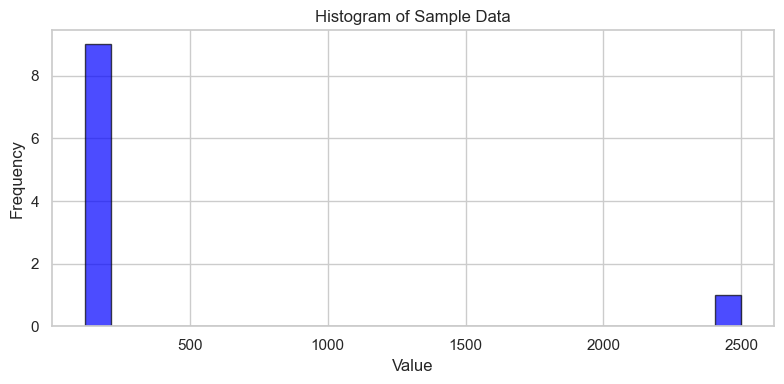

In [6]:
plt.figure(figsize=(8, 4))
plt.hist(sample_data, bins=25, color='blue', edgecolor='black', alpha=0.7)
plt.title('Histogram of Sample Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Histogram of gamma-distributed data

Generate a larger dataset from a Gamma distribution to illustrate skewness.

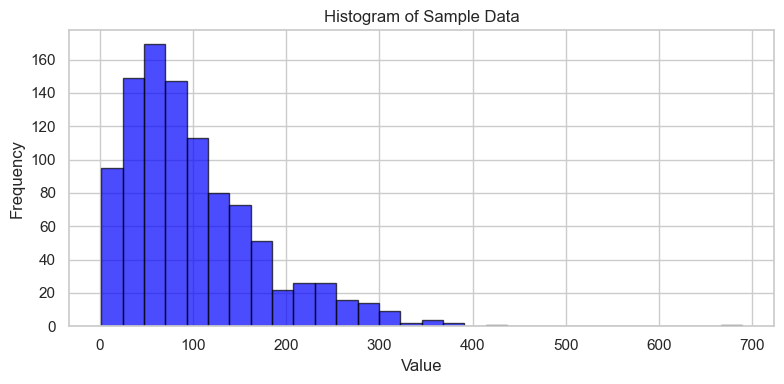

In [7]:
sample_data_gamma = np.random.gamma(shape=2, scale=50, size=1000)

plt.figure(figsize=(8, 4))
plt.hist(sample_data_gamma, bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.title('Histogram of Sample Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Histogram with density on the y-axis

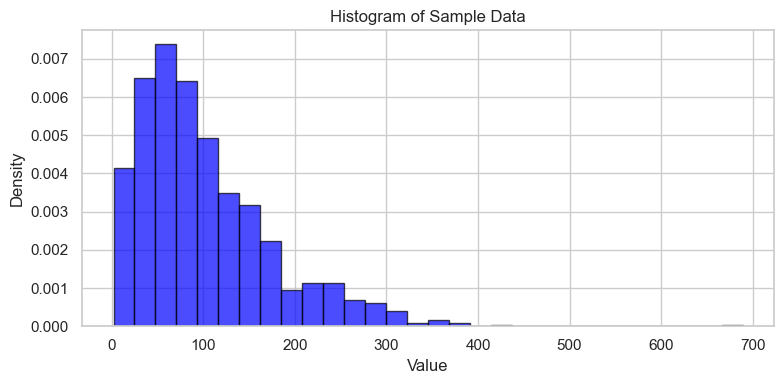

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(sample_data_gamma, bins=30, color='blue', edgecolor='black', alpha=0.7, density=True)
plt.title('Histogram of Sample Data')
plt.xlabel('Value')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

## Part 3: Density Plot

A density plot is a smoothed version of a histogram.

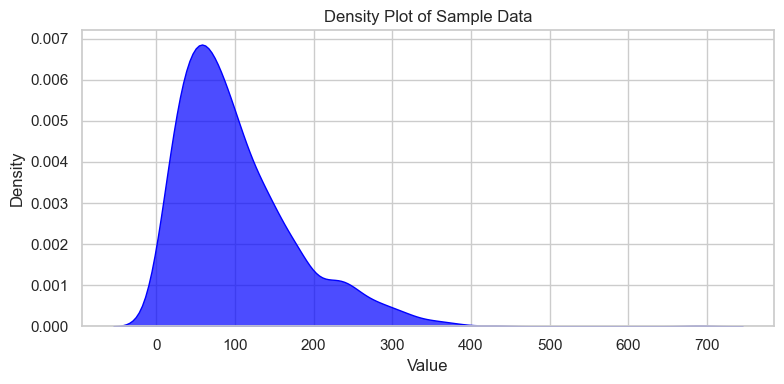

In [9]:
plt.figure(figsize=(8, 4))
sns.kdeplot(sample_data_gamma, fill=True, color='blue', alpha=0.7)
plt.title('Density Plot of Sample Data')
plt.xlabel('Value')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

## Part 4: Violin Plots

A violin plot shows the distribution shape (like a density plot) oriented vertically, making it easy to compare groups.

### Basic violin plot

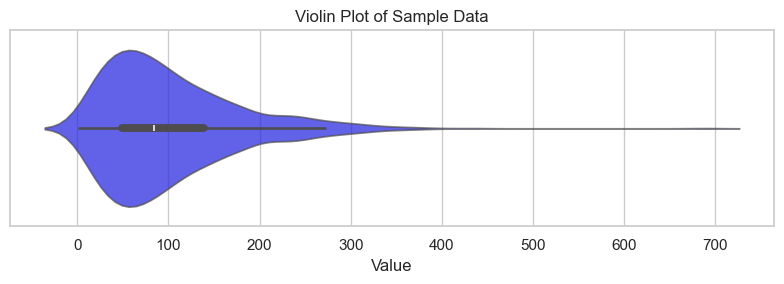

In [10]:
plt.figure(figsize=(8, 3))
sns.violinplot(x=sample_data_gamma, color='blue', alpha=0.7)
plt.title('Violin Plot of Sample Data')
plt.xlabel('Value')
plt.tight_layout()
plt.show()

### Violin plot with jittered data points

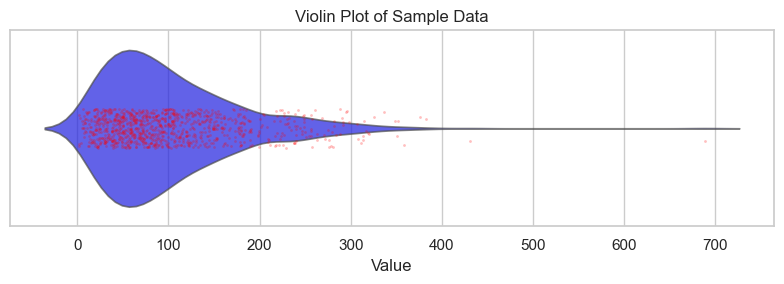

In [11]:
plt.figure(figsize=(8, 3))
sns.violinplot(x=sample_data_gamma, color='blue', alpha=0.7, inner=None)
sns.stripplot(x=sample_data_gamma, color='red', alpha=0.25, jitter=True, size=2)
plt.title('Violin Plot of Sample Data')
plt.xlabel('Value')
plt.tight_layout()
plt.show()

## Part 5: Boxplot

A boxplot displays the median, quartiles (Q1, Q3), and potential outliers.

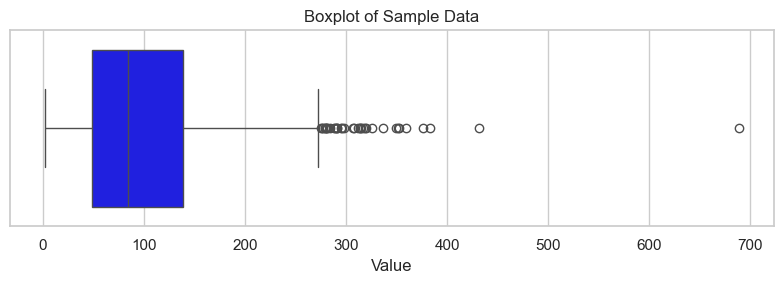

In [15]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=sample_data_gamma, color='blue')
plt.title('Boxplot of Sample Data')
plt.xlabel('Value')
plt.tight_layout()
plt.show()

## Part 6: Violin + Boxplot Combo with Distribution Markers

Combining a violin plot with a boxplot and labeled summary statistics (min, Q1, median, Q3, max as red diamonds; mean as a black dot).

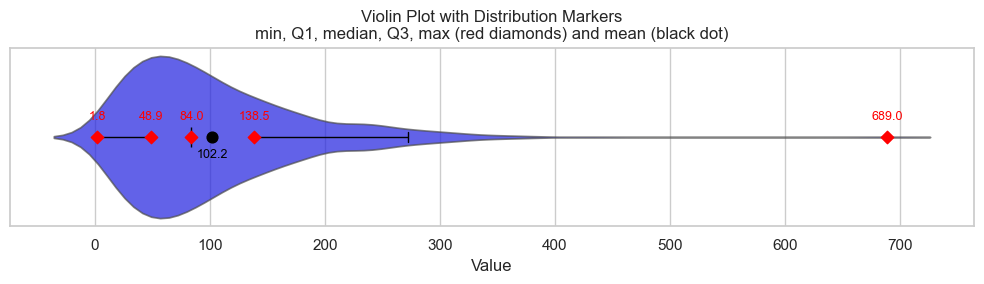

In [16]:
fig, ax = plt.subplots(figsize=(10, 3))

# Violin
sns.violinplot(x=sample_data_gamma, color='blue', alpha=0.7, inner=None, ax=ax)

# Overlay a thin boxplot
sns.boxplot(x=sample_data_gamma, width=0.1, color='white',
            boxprops=dict(alpha=0), whiskerprops=dict(color='black'),
            medianprops=dict(color='black'), capprops=dict(color='black'),
            flierprops=dict(marker=''), ax=ax)

# Compute summary statistics
q_vals = np.percentile(sample_data_gamma, [0, 25, 50, 75, 100])
mean_val = np.mean(sample_data_gamma)

# Plot quartile diamonds (red) and mean (black)
ax.scatter(q_vals, [0]*5, color='red', marker='D', s=40, zorder=5)
ax.scatter([mean_val], [0], color='black', s=60, zorder=5)

# Label quartiles
for v in q_vals:
    ax.annotate(f'{v:.1f}', xy=(v, 0), xytext=(0, 12),
                textcoords='offset points', ha='center', color='red', fontsize=9)

# Label mean
ax.annotate(f'{mean_val:.1f}', xy=(mean_val, 0), xytext=(0, -15),
            textcoords='offset points', ha='center', color='black', fontsize=9)

ax.set_title('Violin Plot with Distribution Markers\n'
             'min, Q1, median, Q3, max (red diamonds) and mean (black dot)')
ax.set_xlabel('Value')
plt.tight_layout()
plt.show()

## Part 7: Histogram with Boxplot Underneath

Stacking a histogram above a boxplot gives a combined view of the distribution shape and its five-number summary.

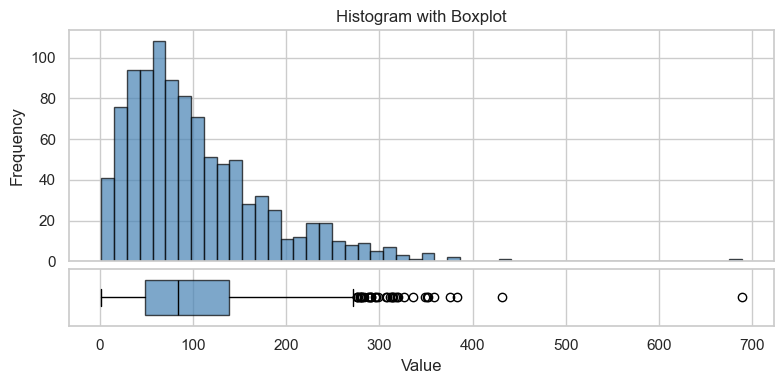

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4),
                               gridspec_kw={'height_ratios': [4, 1]},
                               sharex=True)

# Histogram (top)
ax1.hist(sample_data_gamma, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_title('Histogram with Boxplot')
ax1.set_ylabel('Frequency')
ax1.tick_params(axis='x', labelbottom=False)

# Boxplot (bottom)
ax2.boxplot(sample_data_gamma, vert=False, widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7),
            medianprops=dict(color='black'))
ax2.set_xlabel('Value')
ax2.set_yticks([])

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.show()

## Part 8: Bar Plots

Bar plots are used to visualize the counts (frequencies) of categorical or discrete variables.

### Bar plot of binomial-distributed data

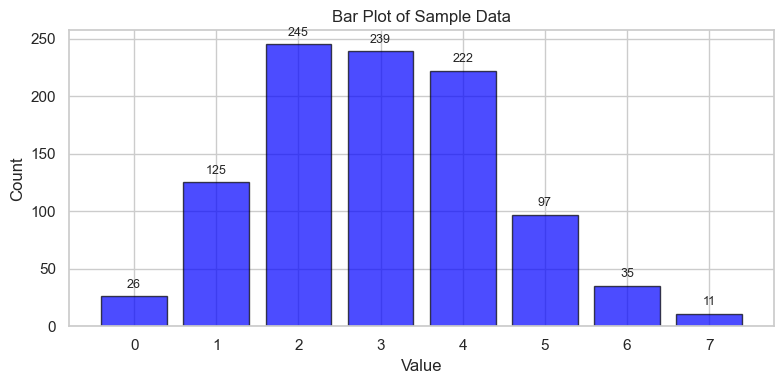

In [18]:
sample_data_binomial = np.random.binomial(n=10, p=0.3, size=1000)

values, counts = np.unique(sample_data_binomial, return_counts=True)

plt.figure(figsize=(8, 4))
bars = plt.bar(values, counts, color='blue', edgecolor='black', alpha=0.7)

# Add count labels above each bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=9)

plt.title('Bar Plot of Sample Data')
plt.xlabel('Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Bar plot of categorical data

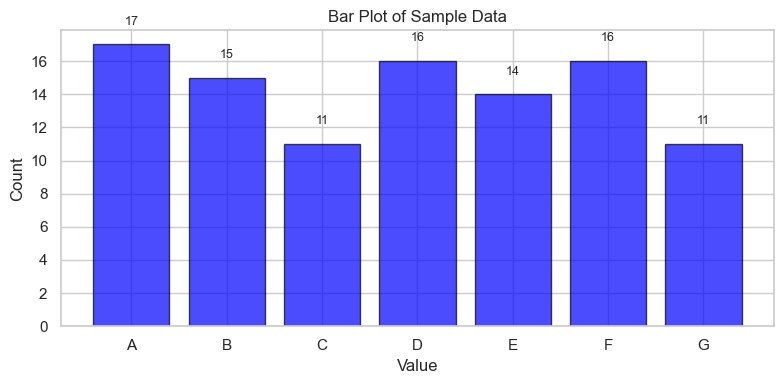

In [19]:
categories = np.random.choice(['A', 'B', 'C', 'D', 'E', 'F', 'G'], size=100)
values, counts = np.unique(categories, return_counts=True)

plt.figure(figsize=(8, 4))
bars = plt.bar(values, counts, color='blue', edgecolor='black', alpha=0.7)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', va='bottom', fontsize=9)

plt.title('Bar Plot of Sample Data')
plt.xlabel('Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Part 9: Building a Violin Plot Step by Step

This section demonstrates how to build up a plot layer by layer, starting from a bare violin and progressively adding data points, labels, summary statistics, and theme adjustments.

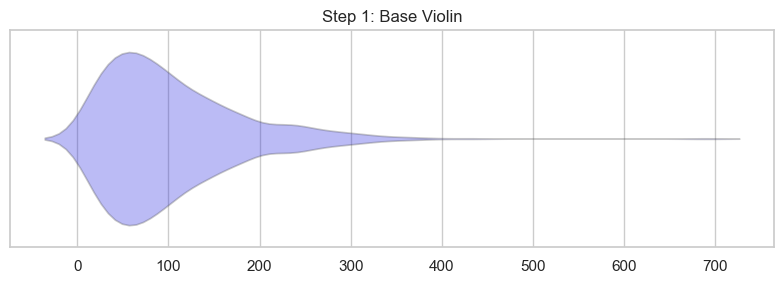

In [20]:
# Step 1: Base violin
fig, ax = plt.subplots(figsize=(8, 3))
sns.violinplot(x=sample_data_gamma, color='blue', alpha=0.3, inner=None, ax=ax)
plt.title('Step 1: Base Violin')
plt.tight_layout()
plt.show()

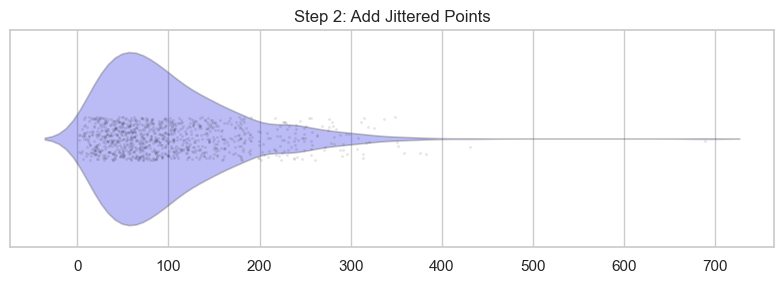

In [21]:
# Step 2: Add jittered data points
fig, ax = plt.subplots(figsize=(8, 3))
sns.violinplot(x=sample_data_gamma, color='blue', alpha=0.3, inner=None, ax=ax)
sns.stripplot(x=sample_data_gamma, color='black', alpha=0.1, jitter=True, size=2, ax=ax)
plt.title('Step 2: Add Jittered Points')
plt.tight_layout()
plt.show()

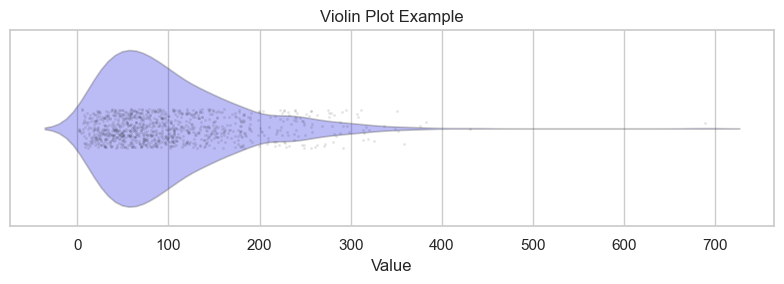

In [22]:
# Step 3: Add title and axis labels
fig, ax = plt.subplots(figsize=(8, 3))
sns.violinplot(x=sample_data_gamma, color='blue', alpha=0.3, inner=None, ax=ax)
sns.stripplot(x=sample_data_gamma, color='black', alpha=0.1, jitter=True, size=2, ax=ax)
ax.set_title('Violin Plot Example')
ax.set_xlabel('Value')
plt.tight_layout()
plt.show()

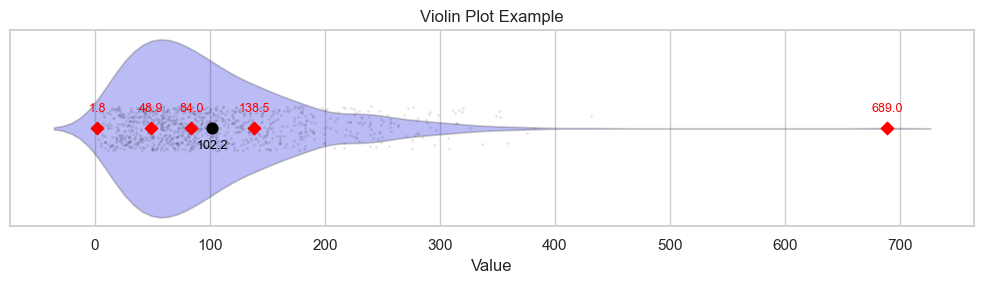

In [23]:
# Step 4: Add quartile markers and mean with labels
fig, ax = plt.subplots(figsize=(10, 3))
sns.violinplot(x=sample_data_gamma, color='blue', alpha=0.3, inner=None, ax=ax)
sns.stripplot(x=sample_data_gamma, color='black', alpha=0.1, jitter=True, size=2, ax=ax)

q_vals = np.percentile(sample_data_gamma, [0, 25, 50, 75, 100])
mean_val = np.mean(sample_data_gamma)

ax.scatter(q_vals, [0]*5, color='red', marker='D', s=40, zorder=5)
ax.scatter([mean_val], [0], color='black', s=60, zorder=5)

for v in q_vals:
    ax.annotate(f'{v:.1f}', xy=(v, 0), xytext=(0, 12),
                textcoords='offset points', ha='center', color='red', fontsize=9)
ax.annotate(f'{mean_val:.1f}', xy=(mean_val, 0), xytext=(0, -15),
            textcoords='offset points', ha='center', color='black', fontsize=9)

ax.set_title('Violin Plot Example')
ax.set_xlabel('Value')
plt.tight_layout()
plt.show()

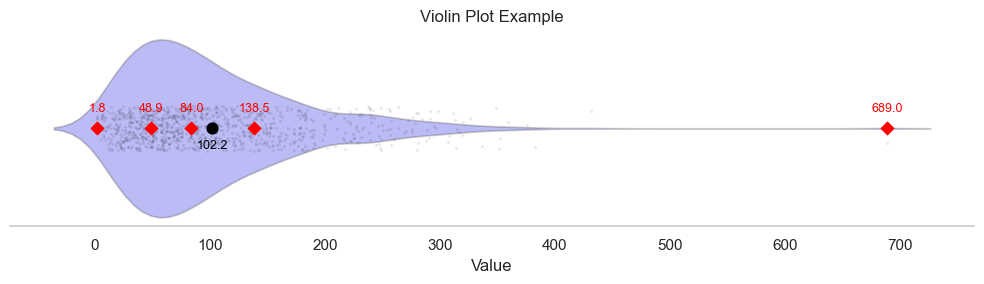

In [24]:
# Step 5: Clean up the theme
fig, ax = plt.subplots(figsize=(10, 3))
sns.violinplot(x=sample_data_gamma, color='blue', alpha=0.3, inner=None, ax=ax)
sns.stripplot(x=sample_data_gamma, color='black', alpha=0.1, jitter=True, size=2, ax=ax)

q_vals = np.percentile(sample_data_gamma, [0, 25, 50, 75, 100])
mean_val = np.mean(sample_data_gamma)

ax.scatter(q_vals, [0]*5, color='red', marker='D', s=40, zorder=5)
ax.scatter([mean_val], [0], color='black', s=60, zorder=5)

for v in q_vals:
    ax.annotate(f'{v:.1f}', xy=(v, 0), xytext=(0, 12),
                textcoords='offset points', ha='center', color='red', fontsize=9)
ax.annotate(f'{mean_val:.1f}', xy=(mean_val, 0), xytext=(0, -15),
            textcoords='offset points', ha='center', color='black', fontsize=9)

ax.set_title('Violin Plot Example')
ax.set_xlabel('Value')
ax.set_yticks([])
ax.grid(False)
sns.despine(left=True)
plt.tight_layout()
plt.show()